# `log_20260422_143345.csv` Review

This notebook starts the review for the latest recirculation log. For now it only loads the prepared flow-log view and draws the general full-log overview.

In [1]:
from dataclasses import replace
from pathlib import Path
import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython import get_ipython
from IPython.display import Markdown, display
import orca

warnings.filterwarnings(
    'ignore',
    message='FigureCanvasAgg is non-interactive, and thus cannot be shown',
    category=UserWarning,
)

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('load_ext', 'autoreload')
    except Exception:
        pass
    ip.run_line_magic('autoreload', '2')

try:
    import orca.logbook as orca_logbook
    importlib.reload(orca_logbook)
except Exception:
    pass
orca = importlib.reload(orca)

NB_PATH = Path.cwd()
REPO_ROOT = NB_PATH
for candidate in [NB_PATH, *NB_PATH.parents]:
    if (candidate / 'data').exists() and (candidate / 'analysis').exists():
        REPO_ROOT = candidate
        break

LOG_PATH = REPO_ROOT / 'data' / 'raw' / 'recirculation' / 'log_20260422_143345.csv'
TC_CALIBRATION_PATH = REPO_ROOT / 'data' / 'processed' / 'calibration' / 'TC_calibration_20260420.csv'
print(f'Repo root: {REPO_ROOT}')
print(f'Log path: {LOG_PATH}')
print(f'TC calibration: {TC_CALIBRATION_PATH}')

Repo root: /home/aamy/Documents/hfe-system
Log path: /home/aamy/Documents/hfe-system/data/raw/recirculation/log_20260422_143345.csv
TC calibration: /home/aamy/Documents/hfe-system/data/processed/calibration/TC_calibration_20260420.csv


In [2]:
review = orca.prepare_flow_log_review(LOG_PATH, tc_calibration_path=TC_CALIBRATION_PATH)

data = review.data.copy().sort_values('time_s').reset_index(drop=True)
valid_temp_cols = tuple(col for col in review.valid_temp_cols if col in data.columns)
if valid_temp_cols:
    data['temp_mean_C'] = data[list(valid_temp_cols)].mean(axis=1)
    data['temp_min_C'] = data[list(valid_temp_cols)].min(axis=1)
    data['temp_max_C'] = data[list(valid_temp_cols)].max(axis=1)
    data['temp_span_C'] = data['temp_max_C'] - data['temp_min_C']
segment_summary = orca.build_segment_summary(data)
if review.run_segment_id in segment_summary.index:
    run_segment_id = review.run_segment_id
elif segment_summary['use_for_quantitative_flow'].any():
    run_segment_id = int(segment_summary.loc[segment_summary['use_for_quantitative_flow'], 'duration_s'].idxmax())
else:
    run_segment_id = int(segment_summary['duration_s'].idxmax())
review = replace(
    review,
    data=data,
    valid_temp_cols=valid_temp_cols,
    segment_summary=segment_summary,
    run_segment_id=run_segment_id,
)

display(Markdown(
    f'Applied restored-log thermocouple calibration in memory from `{TC_CALIBRATION_PATH.name}`. '
    'Raw thermocouple columns are retained as `*_raw_C` when calibration is applied.'
))
display(orca.flow_log_overview_table(review).to_frame())
display(review.segment_summary.round(3))


Applied restored-log thermocouple calibration in memory from `TC_calibration_20260420.csv`. Raw thermocouple columns are retained as `*_raw_C` when calibration is applied.

,value
flow_note,"This CSV already looks SI-like, so the noteboo..."
rows,11210
time_start_s,15804.977
time_end_s,39121.867
run_segment_id,1
dominant_command_pct,40.0
stable_hold_start_s,16060.933
stable_hold_end_s,16475.142
stable_hold_duration_s,414.209
valid_thermocouples,"TFO, TTI, TTO, TMI, THM, THI"


,start_s,end_s,duration_s,cmd_level_count,pump_cmd_levels_pct,median_freq_hz,max_freq_hz,median_mass_flow_kgmin,median_volume_flow_lmin,median_density_kg_m3,median_flow_temp_C,liquid_fraction,positive_mass_flow_fraction,flow_temp_change_C,density_change_kg_m3,classification,use_for_quantitative_flow
segment_id,,,,,,,,,,,,,,,,,
1,15817.457,25245.417,9427.96,7,"5, 20, 40, 60, 70, 75, 80",28.14,56.36,4.171,2.64,1564.7,-40.86,1.0,1.0,-51.934,109.477,usable liquid circulation,True


## General Plot

This phase overview keeps the pump-running portion in view, removes the stable-hold highlight, shades the requested operating phases, and marks the bypass open/close events.

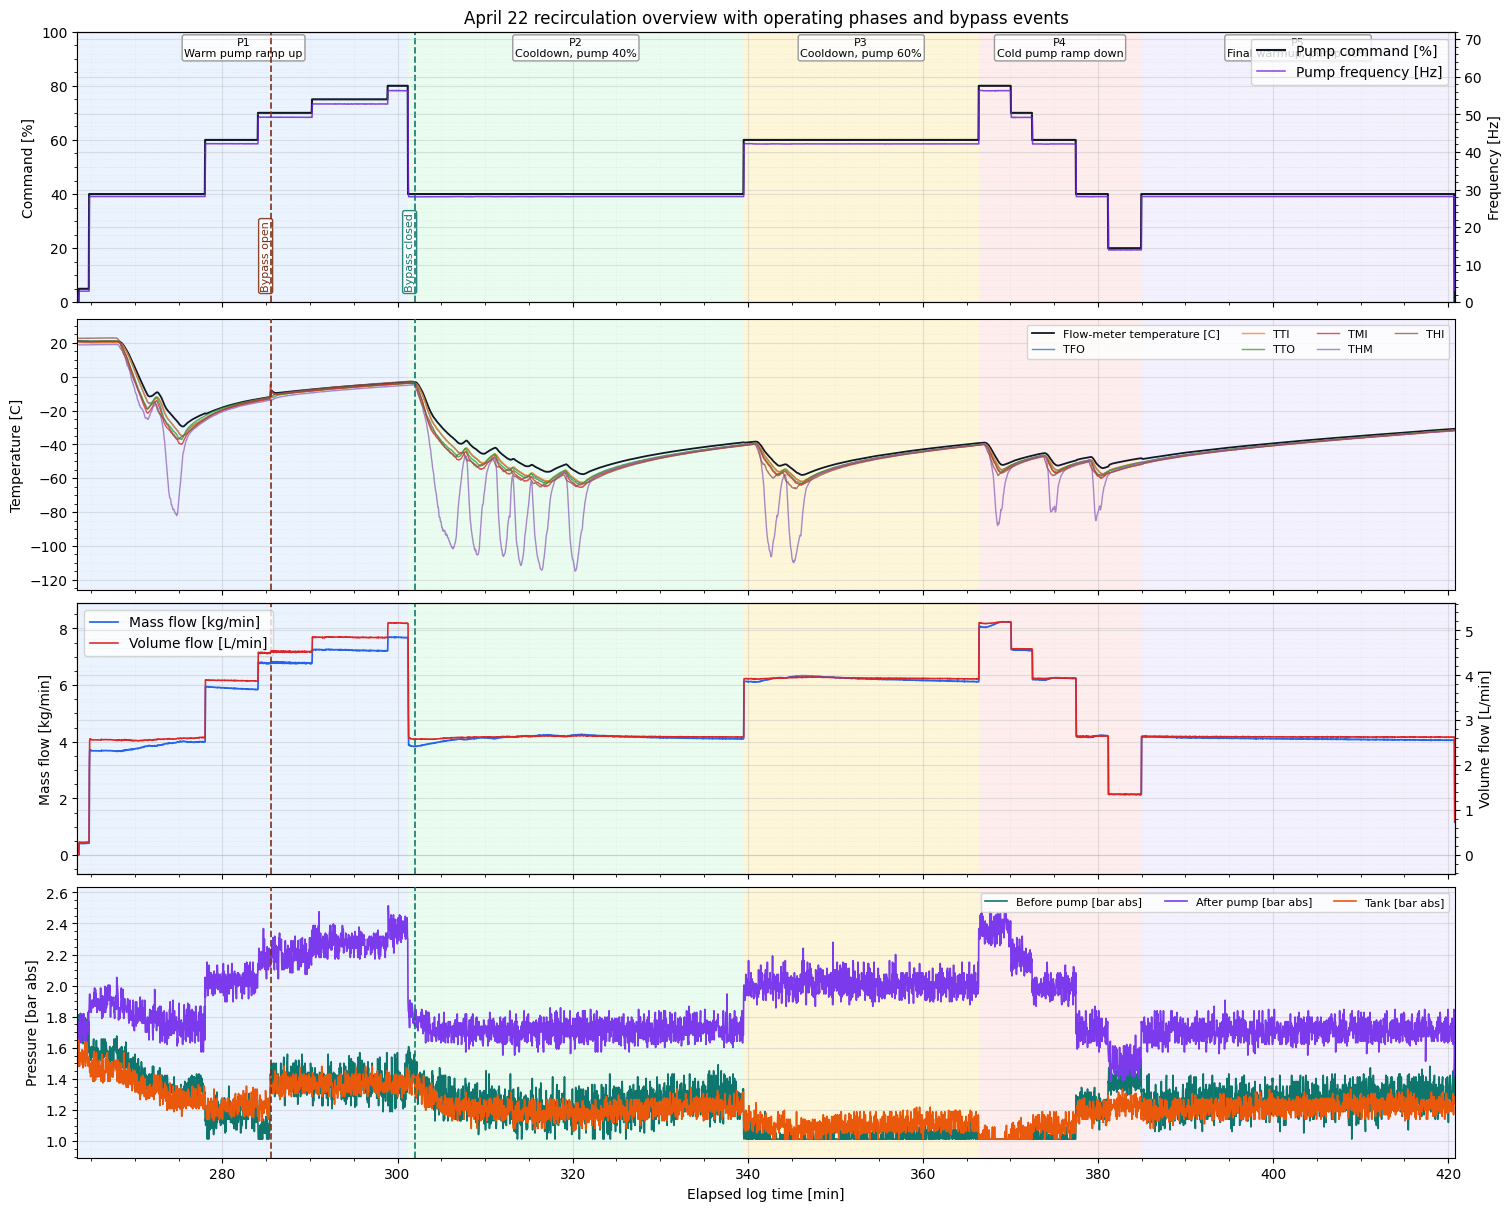

In [3]:
BYPASS_OPEN_MIN = 285.5
BYPASS_CLOSED_MIN = 301.95


def _apply_fine_grid(ax):
    ax.minorticks_on()
    ax.grid(True, which='major', alpha=0.34, linewidth=0.8)
    ax.grid(True, which='minor', alpha=0.16, linestyle=':', linewidth=0.6)


def _command_step_windows(review):
    run = orca.segment_slice(review.data, review.segment_summary.loc[review.run_segment_id]).copy()
    _, windows, _, _ = orca.command_step_summary(run)
    work = windows.copy()
    work['start_min'] = work['start_s'] / 60.0
    work['end_min'] = work['end_s'] / 60.0
    return work


def _phase_defs(review):
    windows = _command_step_windows(review)
    first_start = float(windows['start_min'].iloc[0])
    first_80_to_40 = windows[(windows['cmd_pct'].eq(40.0)) & (windows['start_min'].gt(300.0))].iloc[0]
    p2_end = windows[windows['start_min'].gt(first_80_to_40['start_min']) & windows['cmd_pct'].eq(60.0)].iloc[0]
    p3_end = windows[windows['start_min'].gt(p2_end['start_min']) & windows['cmd_pct'].eq(80.0)].iloc[0]
    p5_start = windows[windows['start_min'].gt(p3_end['start_min']) & windows['cmd_pct'].eq(40.0)].iloc[-1]
    run_end_min = float(review.segment_summary.loc[review.run_segment_id, 'end_s'] / 60.0)
    return [
        ('P1', 'Warm pump ramp up', first_start, float(first_80_to_40['start_min']), '#bfdbfe'),
        ('P2', 'Cooldown, pump 40%', float(first_80_to_40['start_min']), float(p2_end['start_min']), '#bbf7d0'),
        ('P3', 'Cooldown, pump 60%', float(p2_end['start_min']), float(p3_end['start_min']), '#fde68a'),
        ('P4', 'Cold pump ramp down', float(p3_end['start_min']), float(p5_start['start_min']), '#fecaca'),
        ('P5', 'Final warmup, pump 40%', float(p5_start['start_min']), run_end_min, '#ddd6fe'),
    ]


def _shade_phases(ax, phases, *, label=False):
    for phase, title, start_min, end_min, color in phases:
        ax.axvspan(start_min, end_min, color=color, alpha=0.32, lw=0, zorder=0)
        if label:
            midpoint = 0.5 * (start_min + end_min)
            ax.text(
                midpoint,
                0.98,
                f'{phase}\n{title}',
                transform=ax.get_xaxis_transform(),
                ha='center',
                va='top',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.20', fc='white', ec='0.55', alpha=0.88),
            )


def _mark_bypass_events(ax, *, label=False):
    events = [
        (BYPASS_OPEN_MIN, 'Bypass open', '#7c2d12'),
        (BYPASS_CLOSED_MIN, 'Bypass closed', '#0f766e'),
    ]
    for event_min, event_label, color in events:
        ax.axvline(event_min, color=color, ls='--', lw=1.25, alpha=0.95, zorder=5)
        if label:
            ax.text(
                event_min,
                0.04,
                event_label,
                transform=ax.get_xaxis_transform(),
                rotation=90,
                ha='right',
                va='bottom',
                fontsize=8,
                color=color,
                bbox=dict(boxstyle='round,pad=0.18', fc='white', ec=color, alpha=0.88),
            )


def plot_phase_overview(review, *, include_pump_off_tail=False):
    phases = _phase_defs(review)
    run_end_min = phases[-1][3]
    data = review.data.copy().sort_values('time_s')
    if not include_pump_off_tail:
        data = data[data['t_min'].le(run_end_min)].copy()

    fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True, constrained_layout=True)

    for index, ax in enumerate(axes):
        _shade_phases(ax, phases, label=index == 0)
        _mark_bypass_events(ax, label=index == 0)
        _apply_fine_grid(ax)

    ax_cmd = axes[0]
    ax_freq = ax_cmd.twinx()
    ax_cmd.plot(data['t_min'], data['pump_cmd_pct'], label='Pump command [%]', lw=1.5, color='#111827')
    ax_freq.plot(data['t_min'], data['pump_freq_hz'], label='Pump frequency [Hz]', lw=1.1, color='#6d28d9', alpha=0.85)
    ax_cmd.set_ylabel('Command [%]')
    ax_cmd.set_ylim(0.0, 100.0)
    ax_freq.set_ylabel('Frequency [Hz]')
    ax_freq.set_ylim(0.0, max(72.0, 1.08 * float(data['pump_freq_hz'].max())))
    _apply_fine_grid(ax_freq)
    lines = [line for line in ax_cmd.get_lines() + ax_freq.get_lines()
             if not line.get_label().startswith('_')]
    ax_cmd.legend(lines, [line.get_label() for line in lines], loc='upper right')
    ax_cmd.set_title('April 22 recirculation overview with operating phases and bypass events')

    axes[1].plot(data['t_min'], data['temperature_c_si'], lw=1.3, label='Flow-meter temperature [C]', color='#111827')
    for column in review.valid_temp_cols:
        axes[1].plot(data['t_min'], data[column], lw=1.0, alpha=0.78, label=orca.tc_display_name(column))
    temp_values = data[['temperature_c_si', *review.valid_temp_cols]].to_numpy(dtype=float)
    temp_min = float(np.nanmin(temp_values))
    temp_max = float(np.nanmax(temp_values))
    temp_pad = max(3.0, 0.08 * (temp_max - temp_min))
    axes[1].set_ylabel('Temperature [C]')
    axes[1].set_ylim(temp_min - temp_pad, temp_max + temp_pad)
    axes[1].legend(loc='best', ncols=max(1, min(4, len(review.valid_temp_cols) + 1)), fontsize=8)

    ax_mass = axes[2]
    ax_volume = ax_mass.twinx()
    ax_mass.plot(data['t_min'], data['mass_flow_kgmin_si'], color='#2563eb', lw=1.25, label='Mass flow [kg/min]')
    ax_volume.plot(data['t_min'], data['volume_flow_lmin_si'], color='#dc2626', lw=1.15, label='Volume flow [L/min]')
    mass_min = float(np.nanmin(data['mass_flow_kgmin_si']))
    mass_max = float(np.nanmax(data['mass_flow_kgmin_si']))
    mass_pad = max(0.4, 0.08 * (mass_max - mass_min))
    volume_min = float(np.nanmin(data['volume_flow_lmin_si']))
    volume_max = float(np.nanmax(data['volume_flow_lmin_si']))
    volume_pad = max(0.25, 0.08 * (volume_max - volume_min))
    ax_mass.set_ylabel('Mass flow [kg/min]')
    ax_mass.set_ylim(min(-0.3, mass_min - mass_pad), mass_max + mass_pad)
    ax_volume.set_ylabel('Volume flow [L/min]')
    ax_volume.set_ylim(min(-0.2, volume_min - volume_pad), volume_max + volume_pad)
    _apply_fine_grid(ax_volume)
    lines = [line for line in ax_mass.get_lines() + ax_volume.get_lines()
             if not line.get_label().startswith('_')]
    ax_mass.legend(lines, [line.get_label() for line in lines], loc='upper left')

    axes[3].plot(data['t_min'], data['pump_pressure_before_bar_abs'], label='Before pump [bar abs]', lw=1.2, color='#0f766e')
    axes[3].plot(data['t_min'], data['pump_pressure_after_bar_abs'], label='After pump [bar abs]', lw=1.2, color='#7c3aed')
    axes[3].plot(data['t_min'], data['pump_pressure_tank_bar_abs'], label='Tank [bar abs]', lw=1.2, color='#ea580c')
    pressure_cols = ['pump_pressure_before_bar_abs', 'pump_pressure_after_bar_abs', 'pump_pressure_tank_bar_abs']
    pressure_min = float(np.nanmin(data[pressure_cols].to_numpy(dtype=float)))
    pressure_max = float(np.nanmax(data[pressure_cols].to_numpy(dtype=float)))
    pressure_pad = max(0.12, 0.08 * (pressure_max - pressure_min))
    axes[3].set_ylabel('Pressure [bar abs]')
    axes[3].set_ylim(max(0.85, pressure_min - pressure_pad), pressure_max + pressure_pad)
    axes[3].set_xlabel('Elapsed log time [min]')
    axes[3].legend(loc='upper right', ncols=3, fontsize=8)

    x_min = float(data['t_min'].min())
    x_max = float(data['t_min'].max())
    for ax in axes:
        ax.set_xlim(x_min, x_max)
    return fig


plot_phase_overview(review)
plt.show()


## General Plot, With Pump-Off Tail

This optional copy uses the same phase bands and bypass markers but leaves the trailing pump-off warmup visible.

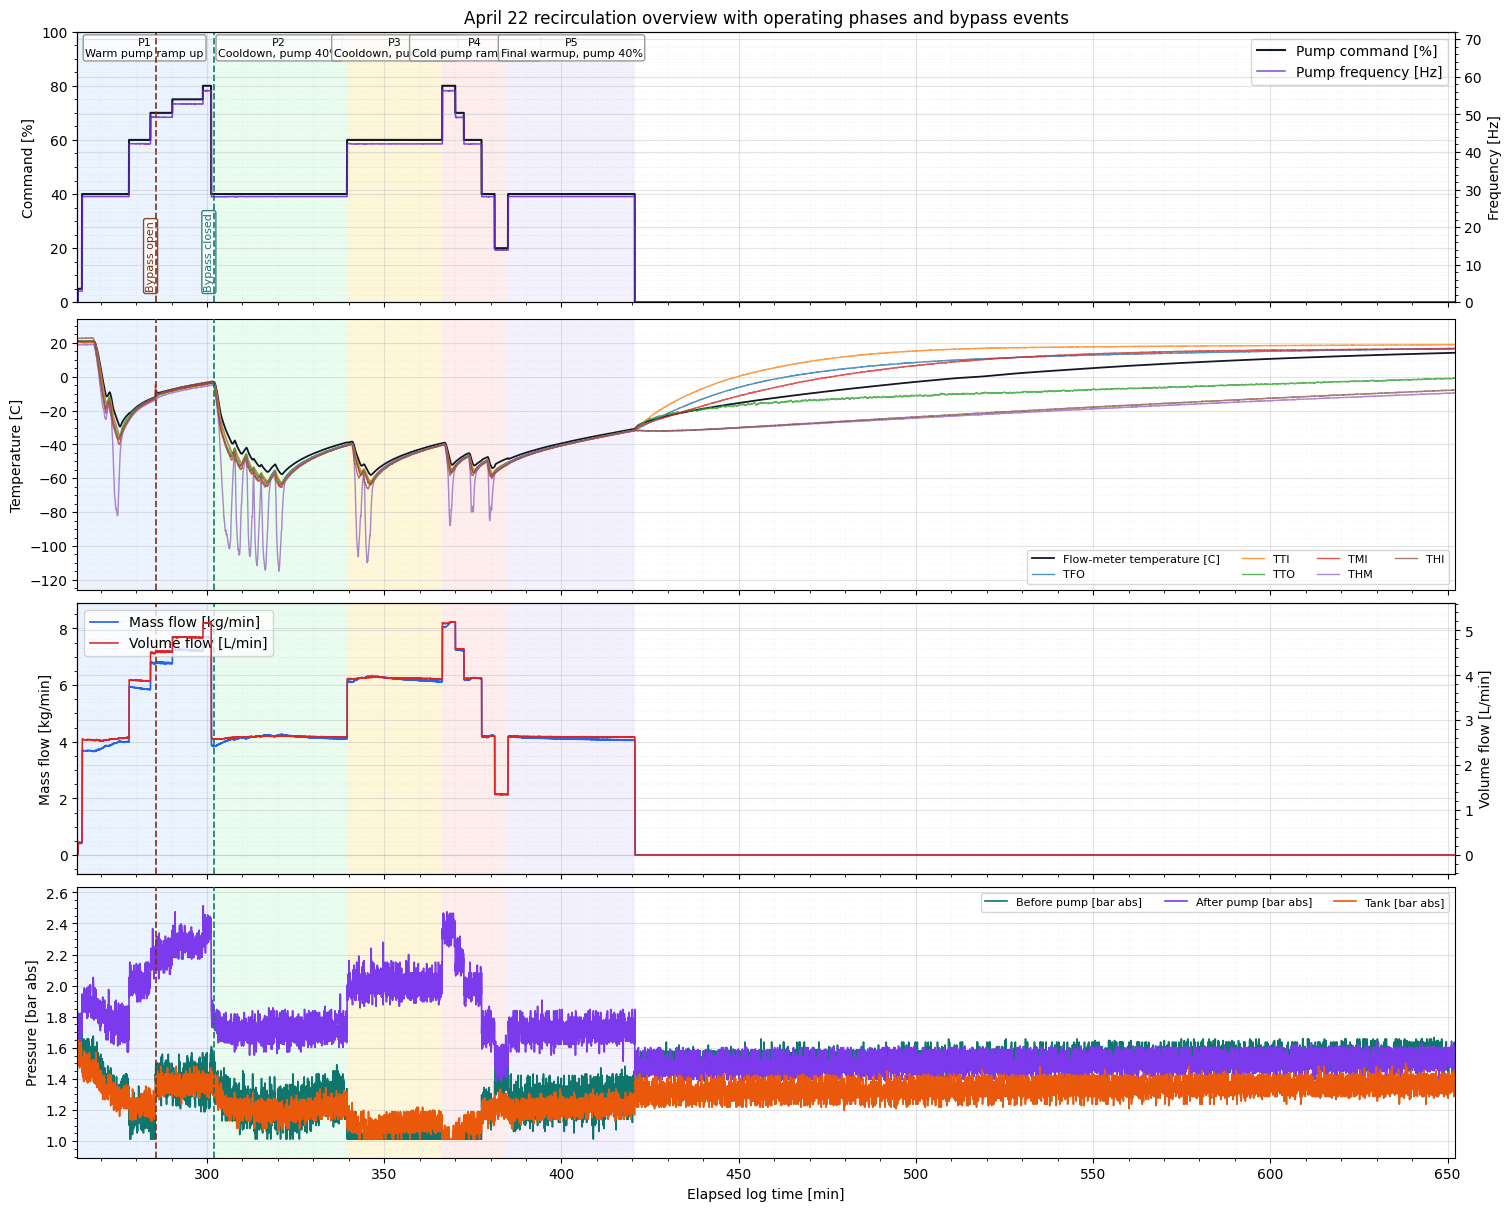

In [4]:
plot_phase_overview(review, include_pump_off_tail=True)
plt.show()

## P2 Temperature Zoom, -70 to -30 C

This view isolates `P2` and fixes the temperature axis to the requested `-70` to `-30 C` range. The flow-meter uncertainty band uses the OPTIMASS 6000 technical-data temperature measurement error: `+/-0.5 C +/-0.5% of reading`.

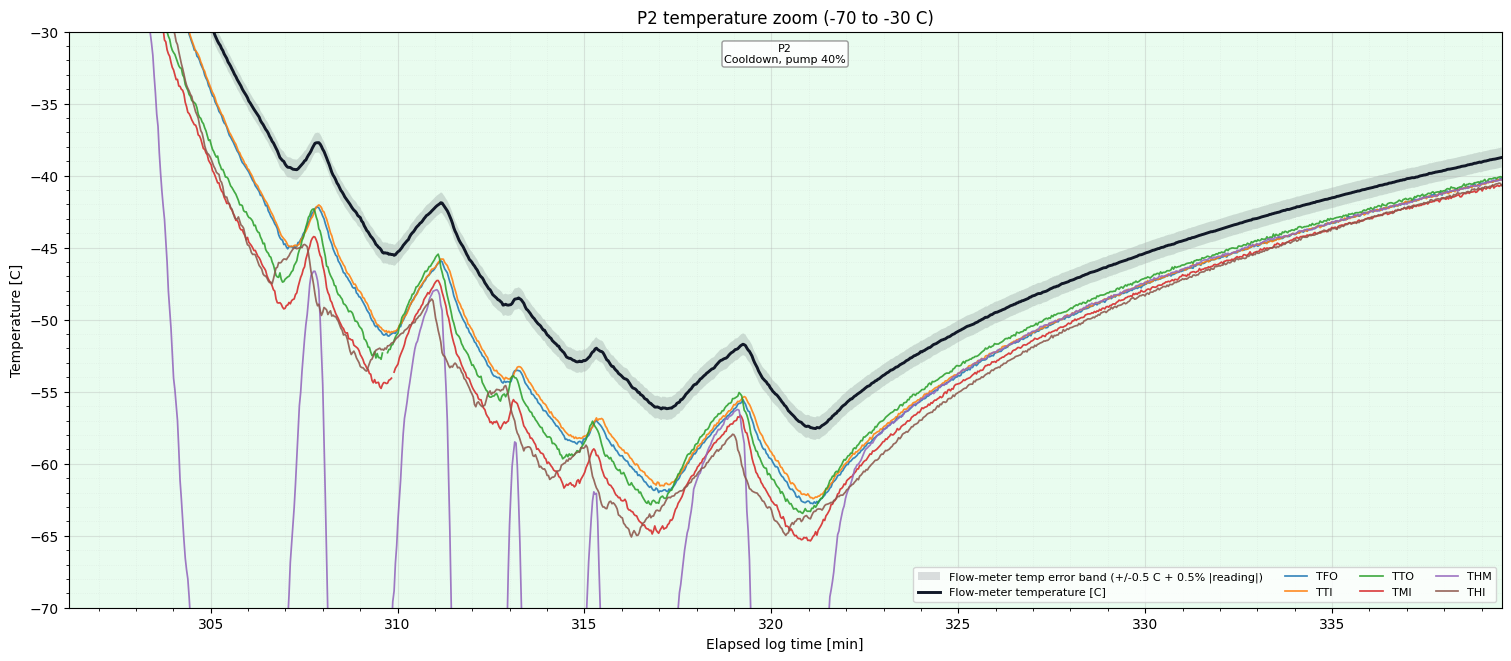

In [5]:
TEMP_ZOOM_PHASE = 'P2'
TEMP_ZOOM_YLIM_C = (-70.0, -30.0)
FLOW_METER_TEMP_ERROR_BASE_C = 0.5
FLOW_METER_TEMP_ERROR_FRACTION = 0.005


def flow_meter_temperature_error_c(temperature_c):
    return FLOW_METER_TEMP_ERROR_BASE_C + FLOW_METER_TEMP_ERROR_FRACTION * np.abs(
        np.asarray(temperature_c, dtype=float)
    )


def plot_temperature_phase_zoom(review, *, phase_key=TEMP_ZOOM_PHASE, y_limits=TEMP_ZOOM_YLIM_C):
    phases = _phase_defs(review)
    phase = next(phase for phase in phases if phase[0] == phase_key)
    phase_start_min = phase[2]
    phase_end_min = phase[3]
    data = review.data[
        review.data['t_min'].between(phase_start_min, phase_end_min)
    ].copy().sort_values('time_s')
    elapsed_min = data['t_min'].to_numpy(dtype=float)
    flow_temp_c = data['temperature_c_si'].to_numpy(dtype=float)
    flow_temp_error_c = flow_meter_temperature_error_c(flow_temp_c)

    fig, ax = plt.subplots(figsize=(15, 6.5), constrained_layout=True)
    _shade_phases(ax, [phase], label=True)

    ax.fill_between(
        elapsed_min,
        flow_temp_c - flow_temp_error_c,
        flow_temp_c + flow_temp_error_c,
        color='#111827',
        alpha=0.14,
        linewidth=0,
        label='Flow-meter temp error band (+/-0.5 C + 0.5% |reading|)',
    )
    ax.plot(
        elapsed_min,
        flow_temp_c,
        lw=2.1,
        label='Flow-meter temperature [C]',
        color='#111827',
    )
    for column in review.valid_temp_cols:
        ax.plot(
            data['t_min'],
            data[column],
            lw=1.25,
            alpha=0.88,
            label=orca.tc_display_name(column),
        )

    _apply_fine_grid(ax)
    ax.set_title(f'{phase_key} temperature zoom (-70 to -30 C)')
    ax.set_xlabel('Elapsed log time [min]')
    ax.set_ylabel('Temperature [C]')
    ax.set_xlim(phase_start_min, phase_end_min)
    ax.set_ylim(*y_limits)
    ax.legend(loc='lower right', ncols=max(1, min(4, len(review.valid_temp_cols) + 2)), fontsize=8)
    return fig


plot_temperature_phase_zoom(review)
plt.show()


## Cold Slowdown Flow Vs Pump Command

This view isolates the cold pump-slowdown / temperature-hold portion after `360 min`.

- The top panels show command medians with P10-P90 spread. The dashed line is the linear trend from commands where the pump inlet is not clipped.
- The middle panel shows percent deviation from that linear reference. Negative values mean less flow than expected.
- The bottom panel shows pump inlet pressure. The red dashed line is the sensor floor near `1 atm`; points at that line should be treated as pressure-limited or clipped.

,samples,dwell_s,median_freq_hz,median_volume_flow_lmin,expected_volume_flow_lmin,volume_flow_deviation_pct,median_inlet_pressure_bar_abs,min_inlet_pressure_bar_abs,inlet_floor_fraction_pct,inlet_pressure_status
cmd_bucket_pct,,,,,,,,,,
20,109,224.823,13.94,1.351,1.351,0.000,1.374,1.296,0.000,not clipped
40,1137,2591.698,28.14,2.631,2.631,0.000,1.267,1.013,0.088,not clipped
60,328,1047.101,42.14,3.930,3.892,0.958,1.013,1.013,57.317,partly clipped
70,70,143.639,49.19,4.586,4.528,1.281,1.013,1.013,100.000,at floor
80,106,218.576,56.29,5.172,5.167,0.083,1.013,1.013,100.000,at floor


1,750 pump-running liquid samples from 360.0 to 420.7 min.
Linear volume-flow reference fitted vs actual pump frequency from: 20%, 40%.
80% command: 5.172 L/min measured, 5.167 L/min expected, +0.08% deviation; inlet sensor floor for 100% of samples.


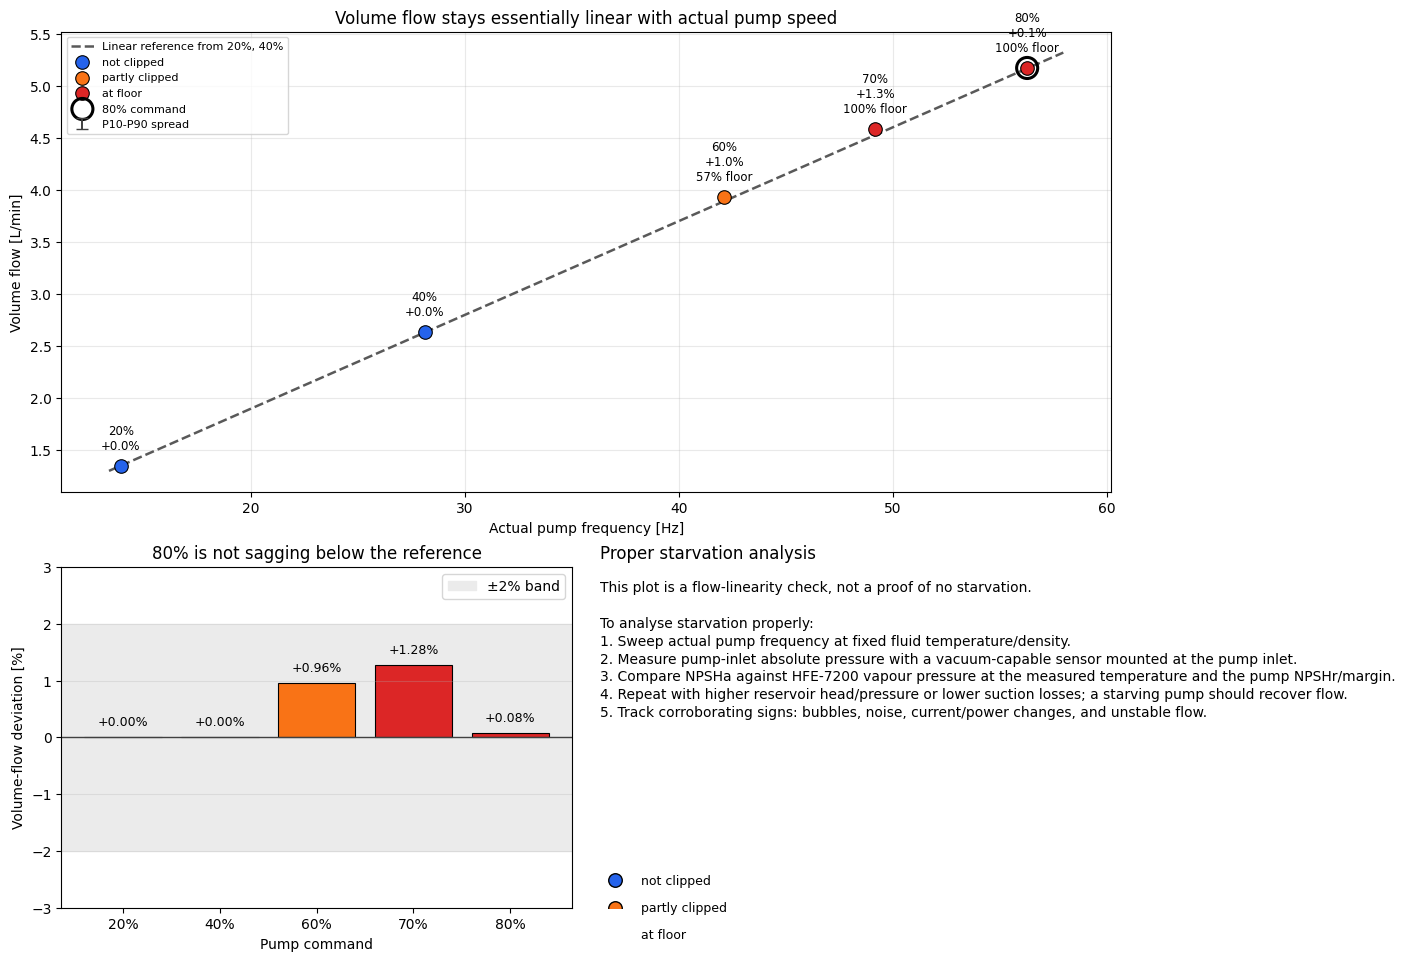

In [6]:
COLD_SLOWDOWN_START_MIN = 360.0
INLET_SENSOR_FLOOR_BAR_ABS = 1.01325

cold_slowdown = review.data[
    review.data['t_min'].ge(COLD_SLOWDOWN_START_MIN)
    & review.data['pump_running']
    & review.data['liquid_like_density']
    & review.data['pump_cmd_pct'].gt(0.0)
].copy()
cold_slowdown['cmd_bucket_pct'] = cold_slowdown['pump_cmd_pct'].round(0)

cold_command_summary = cold_slowdown.groupby('cmd_bucket_pct').agg(
    samples=('time_s', 'size'),
    dwell_s=('time_s', lambda series: float(series.max() - series.min())),
    median_freq_hz=('pump_freq_hz', 'median'),
    median_volume_flow_lmin=('volume_flow_lmin_si', 'median'),
    p10_volume_flow_lmin=('volume_flow_lmin_si', lambda series: series.quantile(0.10)),
    p90_volume_flow_lmin=('volume_flow_lmin_si', lambda series: series.quantile(0.90)),
    median_inlet_pressure_bar_abs=('pump_pressure_before_bar_abs', 'median'),
    p10_inlet_pressure_bar_abs=('pump_pressure_before_bar_abs', lambda series: series.quantile(0.10)),
    p90_inlet_pressure_bar_abs=('pump_pressure_before_bar_abs', lambda series: series.quantile(0.90)),
    min_inlet_pressure_bar_abs=('pump_pressure_before_bar_abs', 'min'),
    low_inlet_pressure_fraction=(
        'pump_pressure_before_bar_abs',
        lambda series: float(series.le(INLET_SENSOR_FLOOR_BAR_ABS).mean()),
    ),
)
cold_command_summary['inlet_floor_fraction_pct'] = 100.0 * cold_command_summary['low_inlet_pressure_fraction']
cold_command_summary['inlet_pressure_status'] = np.select(
    [
        cold_command_summary['low_inlet_pressure_fraction'].lt(0.05),
        cold_command_summary['low_inlet_pressure_fraction'].lt(0.95),
    ],
    ['not clipped', 'partly clipped'],
    default='at floor',
)

reference = cold_command_summary[cold_command_summary['low_inlet_pressure_fraction'].lt(0.05)]
reference_label = ', '.join(f'{cmd:g}%' for cmd in reference.index)
cmd_values = cold_command_summary.index.to_numpy(dtype=float)
freq_values = cold_command_summary['median_freq_hz'].to_numpy(dtype=float)

if len(reference) >= 2:
    ref_slope, ref_intercept = np.polyfit(
        reference['median_freq_hz'].to_numpy(dtype=float),
        reference['median_volume_flow_lmin'].to_numpy(dtype=float),
        deg=1,
    )
elif len(reference) == 1:
    ref_slope = float(reference['median_volume_flow_lmin'].iloc[0] / reference['median_freq_hz'].iloc[0])
    ref_intercept = 0.0
else:
    ref_slope = float(cold_command_summary['median_volume_flow_lmin'].iloc[0] / freq_values[0])
    ref_intercept = 0.0

cold_command_summary['expected_volume_flow_lmin'] = ref_intercept + ref_slope * freq_values
cold_command_summary['volume_flow_deviation_pct'] = (
    100.0
    * (cold_command_summary['median_volume_flow_lmin'] - cold_command_summary['expected_volume_flow_lmin'])
    / cold_command_summary['expected_volume_flow_lmin']
)

display_cols = [
    'samples',
    'dwell_s',
    'median_freq_hz',
    'median_volume_flow_lmin',
    'expected_volume_flow_lmin',
    'volume_flow_deviation_pct',
    'median_inlet_pressure_bar_abs',
    'min_inlet_pressure_bar_abs',
    'inlet_floor_fraction_pct',
    'inlet_pressure_status',
]
display(cold_command_summary[display_cols].round(3))

print(
    f'{len(cold_slowdown):,} pump-running liquid samples from '
    f'{cold_slowdown["t_min"].min():.1f} to {cold_slowdown["t_min"].max():.1f} min.'
)
print(f'Linear volume-flow reference fitted vs actual pump frequency from: {reference_label}.')
if 80.0 in cold_command_summary.index:
    row80 = cold_command_summary.loc[80.0]
    print(
        f'80% command: {row80["median_volume_flow_lmin"]:.3f} L/min measured, '
        f'{row80["expected_volume_flow_lmin"]:.3f} L/min expected, '
        f'{row80["volume_flow_deviation_pct"]:+.2f}% deviation; '
        f'inlet sensor floor for {row80["inlet_floor_fraction_pct"]:.0f}% of samples.'
    )

status_colors = {
    'not clipped': '#2563eb',
    'partly clipped': '#f97316',
    'at floor': '#dc2626',
}
point_colors = cold_command_summary['inlet_pressure_status'].map(status_colors)

fig = plt.figure(figsize=(14, 9.5), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=[1.35, 1.0])
flow_ax = fig.add_subplot(grid[0, :])
deviation_ax = fig.add_subplot(grid[1, 0])
notes_ax = fig.add_subplot(grid[1, 1])

volume_yerr = np.vstack([
    cold_command_summary['median_volume_flow_lmin'] - cold_command_summary['p10_volume_flow_lmin'],
    cold_command_summary['p90_volume_flow_lmin'] - cold_command_summary['median_volume_flow_lmin'],
])
freq_line = np.linspace(freq_values.min() * 0.96, freq_values.max() * 1.03, 200)
flow_ax.plot(
    freq_line,
    ref_intercept + ref_slope * freq_line,
    color='0.35',
    ls='--',
    lw=1.8,
    label=f'Linear reference from {reference_label}',
)
flow_ax.errorbar(
    freq_values,
    cold_command_summary['median_volume_flow_lmin'],
    yerr=volume_yerr,
    fmt='none',
    ecolor='0.25',
    elinewidth=1.4,
    capsize=4,
    label='P10-P90 spread',
)
for status, color in status_colors.items():
    mask = cold_command_summary['inlet_pressure_status'].eq(status)
    flow_ax.scatter(
        cold_command_summary.loc[mask, 'median_freq_hz'],
        cold_command_summary.loc[mask, 'median_volume_flow_lmin'],
        s=95,
        color=color,
        edgecolor='black',
        linewidth=0.8,
        zorder=3,
        label=status,
    )
if 80.0 in cold_command_summary.index:
    row80 = cold_command_summary.loc[80.0]
    flow_ax.scatter(
        row80['median_freq_hz'],
        row80['median_volume_flow_lmin'],
        s=230,
        facecolors='none',
        edgecolors='black',
        linewidths=2.2,
        zorder=4,
        label='80% command',
    )
for cmd, row in cold_command_summary.iterrows():
    label = f'{cmd:g}%\n{row["volume_flow_deviation_pct"]:+.1f}%'
    if row['inlet_floor_fraction_pct'] >= 5.0:
        label += f'\n{row["inlet_floor_fraction_pct"]:.0f}% floor'
    flow_ax.annotate(
        label,
        (row['median_freq_hz'], row['median_volume_flow_lmin']),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=8.5,
    )
flow_ax.set_xlabel('Actual pump frequency [Hz]')
flow_ax.set_ylabel('Volume flow [L/min]')
flow_ax.set_title('Volume flow stays essentially linear with actual pump speed')
flow_ax.grid(True, alpha=0.28)
flow_ax.legend(loc='best', fontsize=8)

bars = deviation_ax.bar(
    [f'{cmd:g}%' for cmd in cold_command_summary.index],
    cold_command_summary['volume_flow_deviation_pct'],
    color=point_colors,
    edgecolor='black',
    linewidth=0.8,
)
deviation_ax.axhspan(-2.0, 2.0, color='0.92', zorder=0, label='±2% band')
deviation_ax.axhline(0.0, color='0.25', lw=1.0)
for bar, value in zip(bars, cold_command_summary['volume_flow_deviation_pct']):
    offset = 0.15 if value >= 0 else -0.25
    va = 'bottom' if value >= 0 else 'top'
    deviation_ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f'{value:+.2f}%',
        ha='center',
        va=va,
        fontsize=9,
    )
deviation_ax.set_ylabel('Volume-flow deviation [%]')
deviation_ax.set_xlabel('Pump command')
deviation_ax.set_title('80% is not sagging below the reference')
deviation_ax.set_ylim(-3.0, 3.0)
deviation_ax.grid(True, axis='y', alpha=0.28)
deviation_ax.legend(loc='best')

notes_ax.axis('off')
notes_ax.set_title('Proper starvation analysis', loc='left')
notes_ax.text(
    0.0,
    0.96,
    'This plot is a flow-linearity check, not a proof of no starvation.\n\n'
    'To analyse starvation properly:\n'
    '1. Sweep actual pump frequency at fixed fluid temperature/density.\n'
    '2. Measure pump-inlet absolute pressure with a vacuum-capable sensor mounted at the pump inlet.\n'
    '3. Compare NPSHa against HFE-7200 vapour pressure at the measured temperature and the pump NPSHr/margin.\n'
    '4. Repeat with higher reservoir head/pressure or lower suction losses; a starving pump should recover flow.\n'
    '5. Track corroborating signs: bubbles, noise, current/power changes, and unstable flow.',
    transform=notes_ax.transAxes,
    va='top',
    fontsize=10,
    linespacing=1.35,
)
legend_y = 0.08
for status, color in status_colors.items():
    notes_ax.scatter(0.03, legend_y, s=95, color=color, edgecolor='black', transform=notes_ax.transAxes)
    notes_ax.text(0.08, legend_y, status, transform=notes_ax.transAxes, va='center', fontsize=9)
    legend_y -= 0.08

plt.show()